In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip /content/drive/MyDrive/archive.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/Training/glioma/Tr-gl_279.jpg  
  inflating: /content/Training/glioma/Tr-gl_28.jpg  
  inflating: /content/Training/glioma/Tr-gl_280.jpg  
  inflating: /content/Training/glioma/Tr-gl_281.jpg  
  inflating: /content/Training/glioma/Tr-gl_282.jpg  
  inflating: /content/Training/glioma/Tr-gl_283.jpg  
  inflating: /content/Training/glioma/Tr-gl_284.jpg  
  inflating: /content/Training/glioma/Tr-gl_285.jpg  
  inflating: /content/Training/glioma/Tr-gl_286.jpg  
  inflating: /content/Training/glioma/Tr-gl_287.jpg  
  inflating: /content/Training/glioma/Tr-gl_288.jpg  
  inflating: /content/Training/glioma/Tr-gl_289.jpg  
  inflating: /content/Training/glioma/Tr-gl_29.jpg  
  inflating: /content/Training/glioma/Tr-gl_290.jpg  
  inflating: /content/Training/glioma/Tr-gl_291.jpg  
  inflating: /content/Training/glioma/Tr-gl_292.jpg  
  inflating: /content/Training/glioma/Tr-gl_293.jpg  
  inflating: /content/Training/gl

### Brain Tumor Detection System

This system aims to classify brain MRI images into four categories: glioma, meningioma, pituitary tumor, and no tumor, with a target accuracy of 90% or higher. The dataset is structured for training and testing, ensuring a balanced representation of each class.

#### Dataset Overview:

**Training Set:**
- Contains 5,600 human brain MRI images.
- Organized into four classes: glioma, meningioma, pituitary tumor, and no tumor.
- Each class contains 1,400 images, providing a balanced dataset for reliable training of classification models.

**Testing Set:**
- Contains 1,600 human brain MRI images reserved for model evaluation.
- Images are organized into the same four classes as the training set.
- Each class contains 400 images, ensuring fair and unbiased evaluation of trained models.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
import os

from tqdm import tqdm
import itertools


from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, AveragePooling2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

np.random.seed(42)

🗂️ Data Preparation

In [5]:
def make_dataset(path):
    data_path = path

    all_paths = []
    all_labels = []


    all_folders = os.listdir(data_path)

    for folder in all_folders:

        folder_path = os.path.join(data_path , folder)

        all_imgs = os.listdir(folder_path)

        for img in all_imgs:
            image_path = os.path.join(folder_path,img)

            all_paths.append(image_path)

            all_labels.append(folder)


    paths = pd.Series(all_paths, name = "img_path")
    labels = pd.Series(all_labels, name = "img_label")

    return pd.concat([paths, labels], axis=1)

training_data = make_dataset(r'/content/Training')
display(training_data)

testing_data = make_dataset(r'/content/Testing')
display(testing_data)

valid_df, test_df = train_test_split(testing_data, train_size=0.5, shuffle= True, random_state=42)

,img_path,img_label
0,/content/Training/glioma/Tr-gl_484.jpg,glioma
1,/content/Training/glioma/Tr-gl_549.jpg,glioma
2,/content/Training/glioma/Tr-gl_709.jpg,glioma
3,/content/Training/glioma/Tr-gl_900.jpg,glioma
4,/content/Training/glioma/Tr-gl_1008.jpg,glioma
...,...,...
5595,/content/Training/meningioma/Tr-me_371.jpg,meningioma
5596,/content/Training/meningioma/Tr-me_850.jpg,meningioma
5597,/content/Training/meningioma/Tr-me_766.jpg,meningioma
5598,/content/Training/meningioma/Tr-me_1013.jpg,meningioma


,img_path,img_label
0,/content/Testing/glioma/Te-gl_107.jpg,glioma
1,/content/Testing/glioma/Te-gl_218.jpg,glioma
2,/content/Testing/glioma/Te-gl_243.jpg,glioma
3,/content/Testing/glioma/Te-gl_113.jpg,glioma
4,/content/Testing/glioma/Te-gl_189.jpg,glioma
...,...,...
1595,/content/Testing/meningioma/Te-me_192.jpg,meningioma
1596,/content/Testing/meningioma/Te-aug-me_40.jpg,meningioma
1597,/content/Testing/meningioma/Te-me_273.jpg,meningioma
1598,/content/Testing/meningioma/Te-me_57.jpg,meningioma


⚙️ Data Pipeline

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


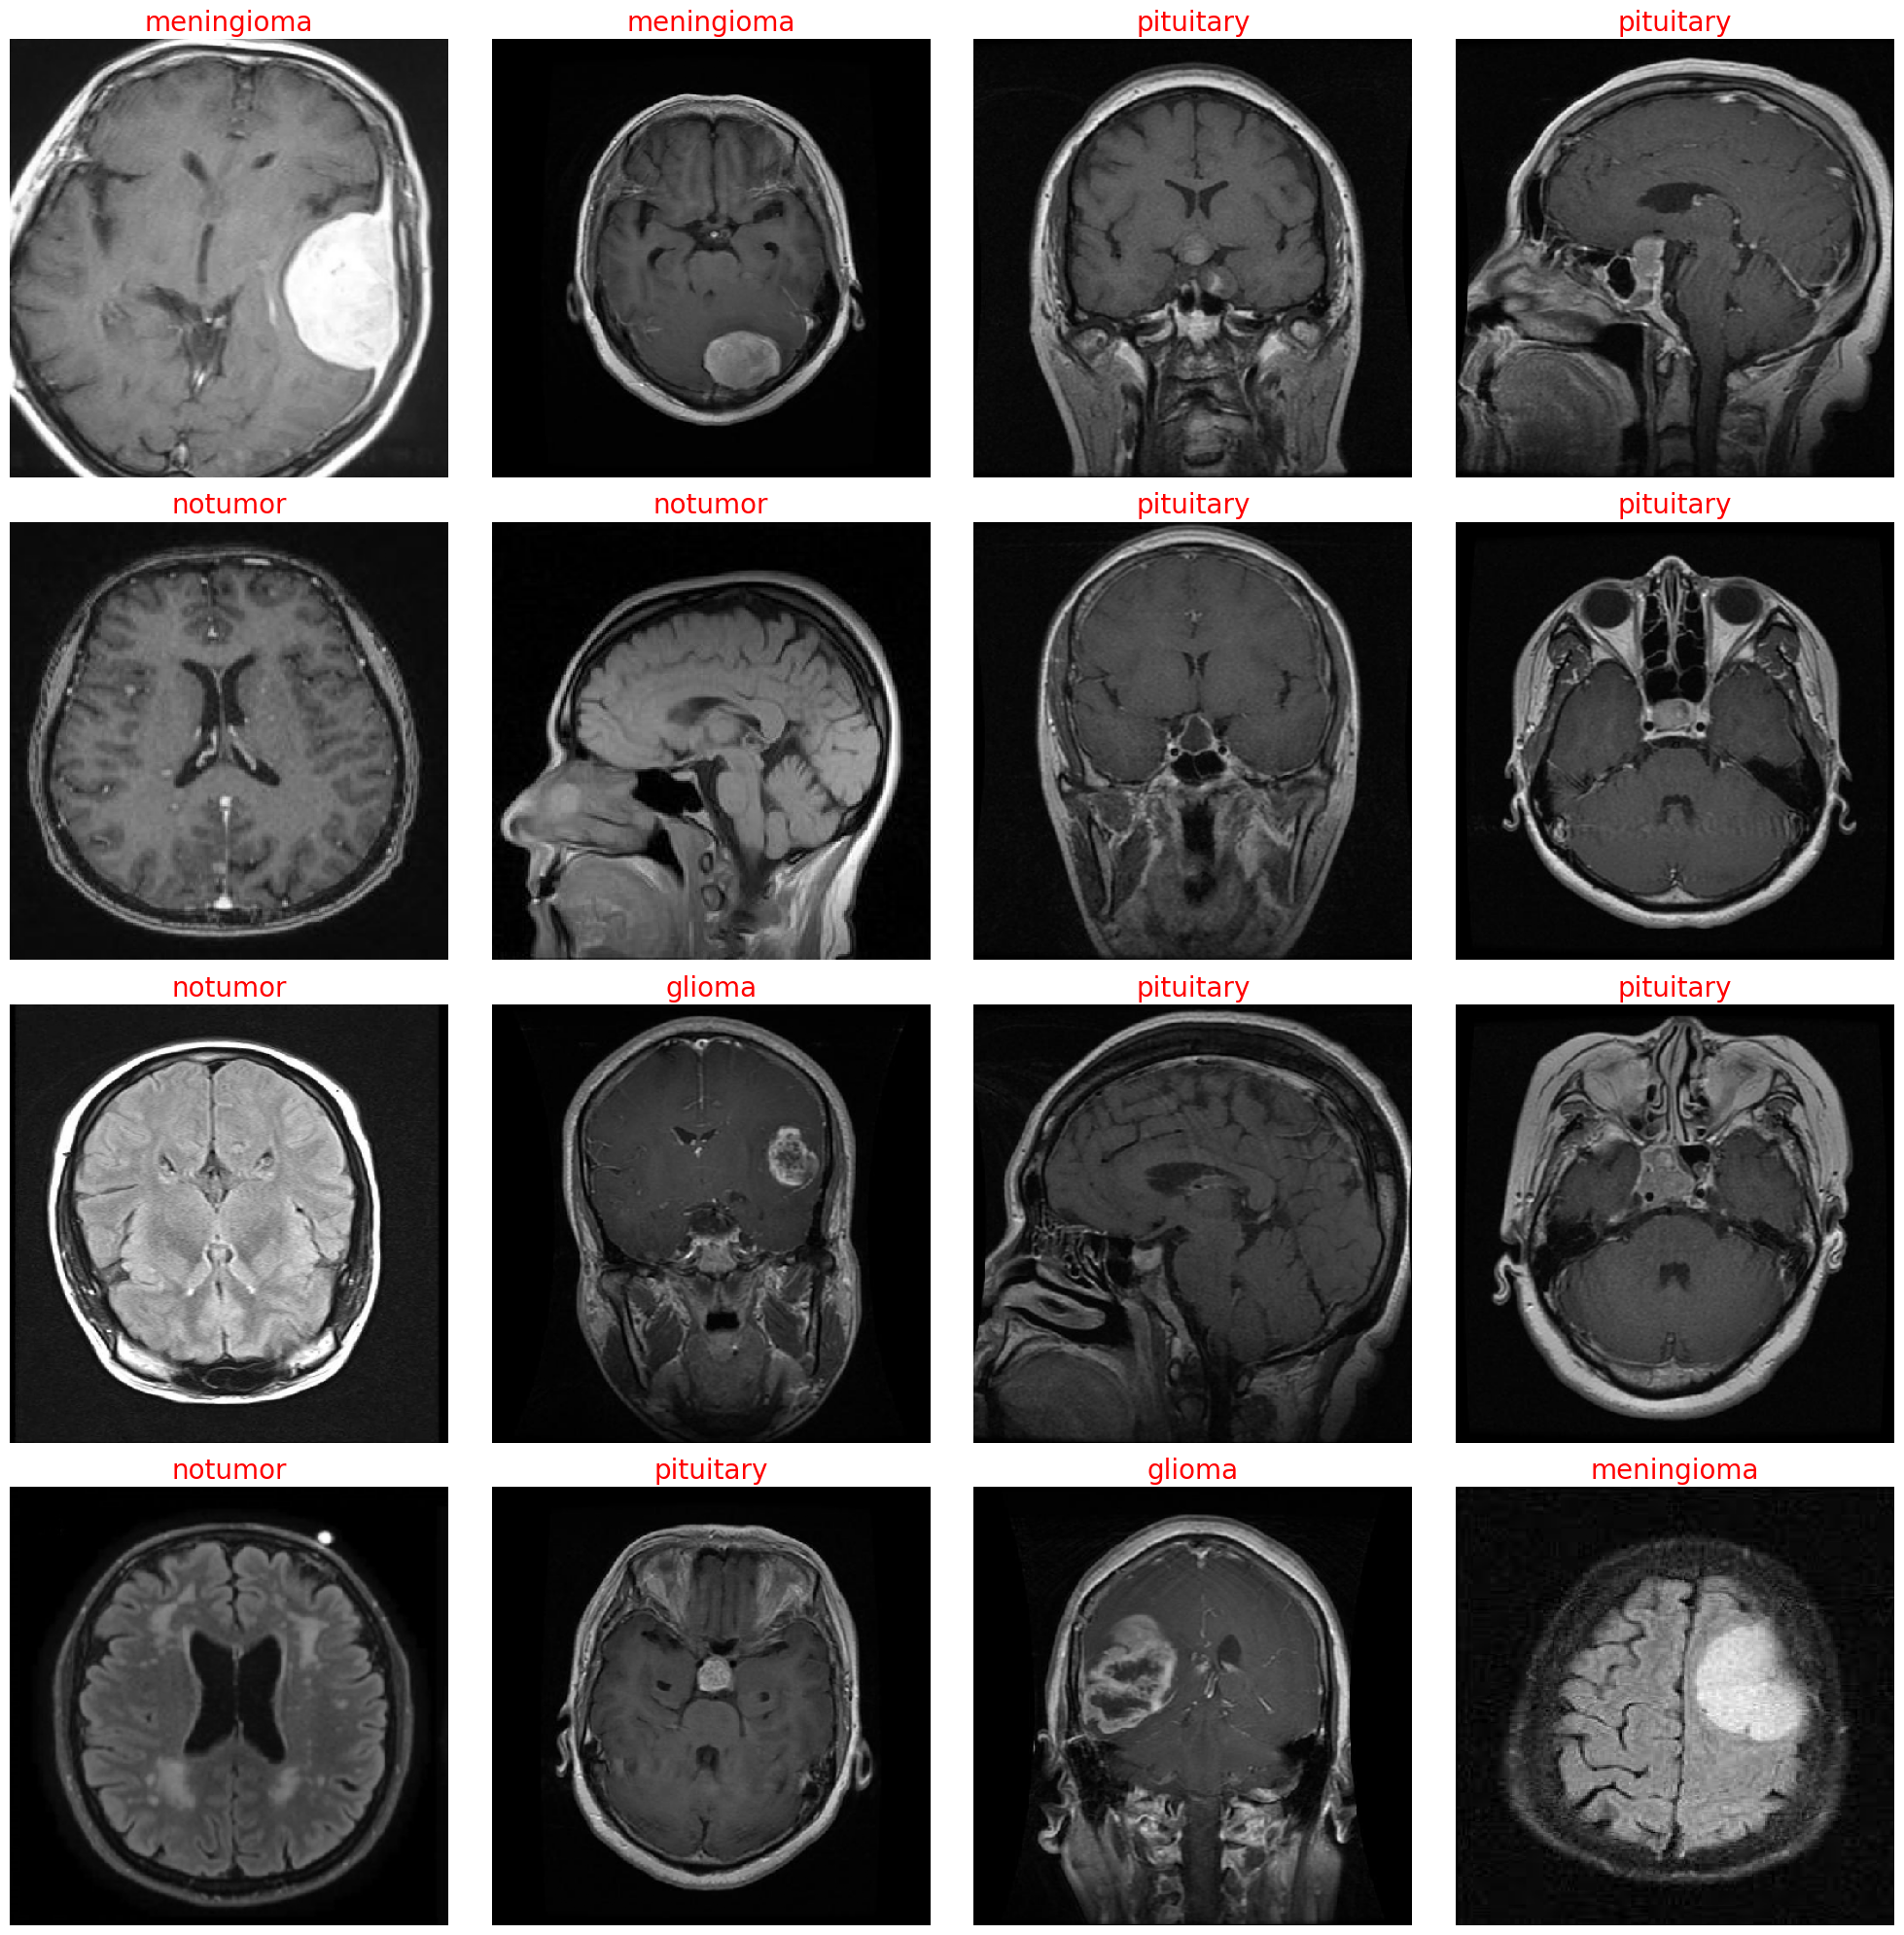

In [6]:
from tensorflow.keras.applications.efficientnet import preprocess_input

batch_size = 16
img_size = (380, 380)

tr_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

ts_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = tr_gen.flow_from_dataframe(
    training_data,
    x_col='img_path',
    y_col='img_label',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

valid_generator = ts_gen.flow_from_dataframe(
    valid_df,
    x_col='img_path',
    y_col='img_label',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

test_generator = ts_gen.flow_from_dataframe(
    test_df,
    x_col='img_path',
    y_col='img_label',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)
gen_dict = train_generator.class_indices
classes = list(gen_dict.keys())

images, labels = next(train_generator)

plt.figure(figsize=(20, 20))

for i in range(16):
    plt.subplot(4, 4, i + 1)

    image = images[i] / 255.0

    # Display the image
    plt.imshow(image , cmap='gray')

    index = np.argmax(labels[i])
    class_name = classes[index]

    plt.title(class_name, color='red', fontsize=20)
    plt.axis('off')

plt.tight_layout()
plt.show()

🏗️ Model Architecture

In [7]:
img_shape = (img_size[0], img_size[1] ,3)
class_count = len(list(train_generator.class_indices.keys()))

strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    base_model = keras.applications.EfficientNetB4(
        include_top=False,
        weights="imagenet",
        input_shape=(380, 380, 3),
        pooling='max',
    )
    base_model.trainable = False

    model = Sequential([
        base_model,
        BatchNormalization(),
        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),
        Dense(4, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb4 (Functional)     │ (None, 1792)           │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1792)           │         7,168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       459,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,174,947 (69.33 MB)

 Trainable params: 496,772 (1.90 MB)

 Non-trainable params: 17,678,175 (67.44 MB)

🏋️ Training

In [8]:
print("🔓 Phase : Transfer Learning with freeze weights")

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=40,
    verbose=1,
    validation_data=valid_generator,
    shuffle=False,
    callbacks=[early_stopping , reduce_lr]
)

🔓 Phase : Transfer Learning with freeze weights
Epoch 1/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 133s 337ms/step - accuracy: 0.7798 - loss: 0.6058 - val_accuracy: 0.8600 - val_loss: 0.4384 - learning_rate: 0.0010
Epoch 2/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 121s 344ms/step - accuracy: 0.8564 - loss: 0.3805 - val_accuracy: 0.8763 - val_loss: 0.4132 - learning_rate: 0.0010
Epoch 3/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 121s 345ms/step - accuracy: 0.8930 - loss: 0.3009 - val_accuracy: 0.8875 - val_loss: 0.3991 - learning_rate: 0.0010
Epoch 4/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 121s 346ms/step - accuracy: 0.9013 - loss: 0.2626 - val_accuracy: 0.9200 - val_loss: 0.3241 - learning_rate: 0.0010
Epoch 5/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 141s 345ms/step - accuracy: 0.9136 - loss: 0.2370 - val_accuracy: 0.9187 - val_loss: 0.3349 - learning_rate: 0.0010
Epoch 6/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 120s 343ms/step - accuracy: 0.9162 - loss: 0.2182 - val_accuracy: 0.9275 - val_loss: 0.3144 - learning_rate: 0.0010
Epoch 7/40
350/3

In [9]:
print("🔓 Phase 2: Fine-tuning entire model")

with strategy.scope():
    base_model.trainable = True  # Unfreeze EfficientNet

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

early_stopping_phase2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_phase2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history_phase2 = model.fit(
    train_generator,
    epochs=40,
    validation_data=valid_generator,
    shuffle=False,
    callbacks=[early_stopping_phase2, reduce_lr_phase2]
)

🔓 Phase 2: Fine-tuning entire model
Epoch 1/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 520s 1s/step - accuracy: 0.8709 - loss: 0.4363 - val_accuracy: 0.8662 - val_loss: 0.6329 - learning_rate: 1.0000e-04
Epoch 2/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 474s 1s/step - accuracy: 0.9516 - loss: 0.1317 - val_accuracy: 0.9250 - val_loss: 0.3733 - learning_rate: 1.0000e-04
Epoch 3/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 473s 1s/step - accuracy: 0.9675 - loss: 0.0873 - val_accuracy: 0.9438 - val_loss: 0.3981 - learning_rate: 1.0000e-04
Epoch 4/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 473s 1s/step - accuracy: 0.9754 - loss: 0.0752 - val_accuracy: 0.9500 - val_loss: 0.2689 - learning_rate: 1.0000e-04
Epoch 5/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 472s 1s/step - accuracy: 0.9773 - loss: 0.0698 - val_accuracy: 0.9563 - val_loss: 0.2434 - learning_rate: 1.0000e-04
Epoch 6/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 473s 1s/step - accuracy: 0.9848 - loss: 0.0469 - val_accuracy: 0.9525 - val_loss: 0.3181 - learning_rate: 1.0000e-04
Epoch 7/40
350/350 ━━━

📈 Results & Evaluation

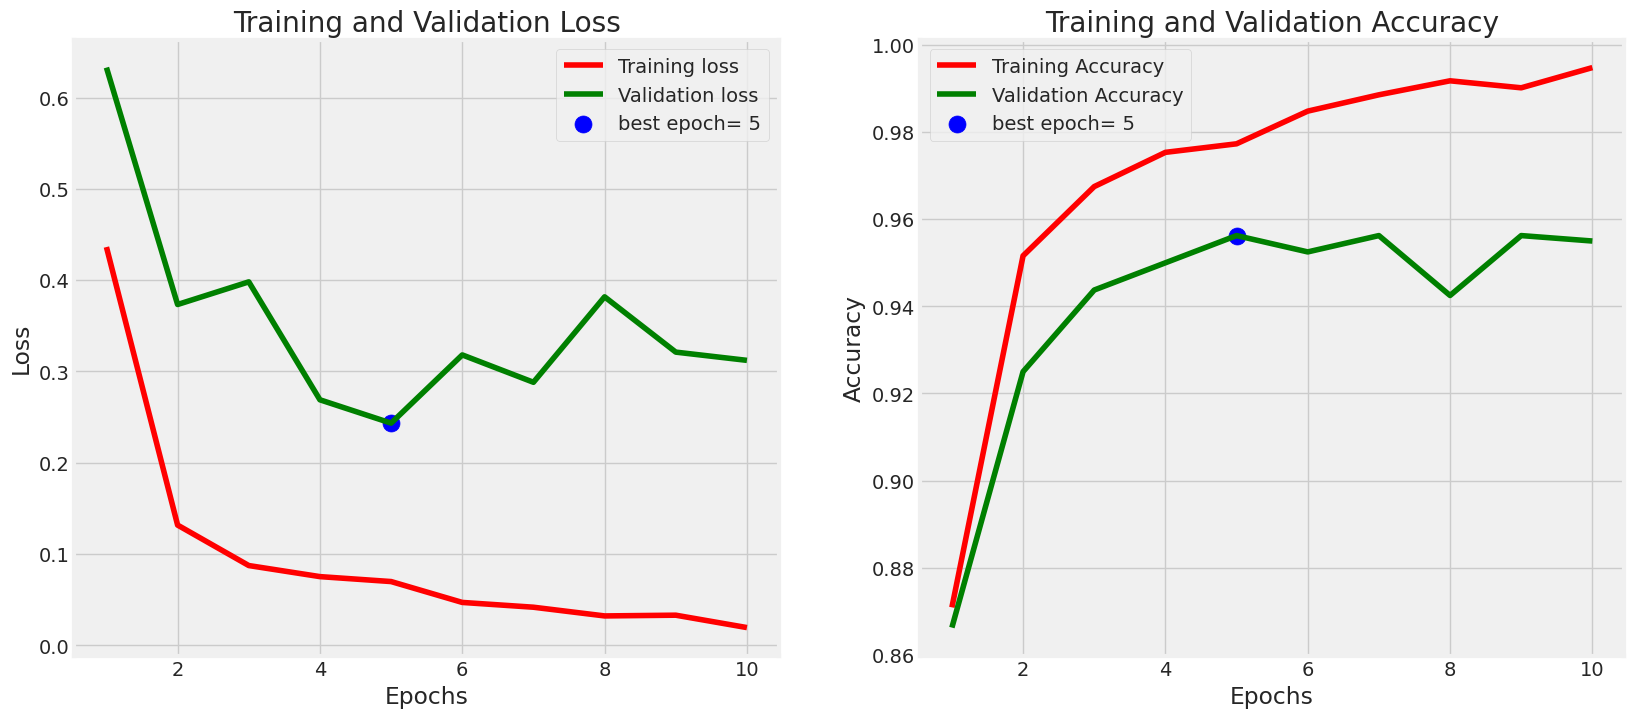

In [10]:
# Define needed variables
tr_acc = history_phase2.history['accuracy']
tr_loss = history_phase2.history['loss']
val_acc = history_phase2.history['val_accuracy']
val_loss = history_phase2.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 284ms/step - accuracy: 0.9550 - loss: 0.2174
Test Accuracy: 95.50%
Test Loss: 0.2174
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 303ms/step


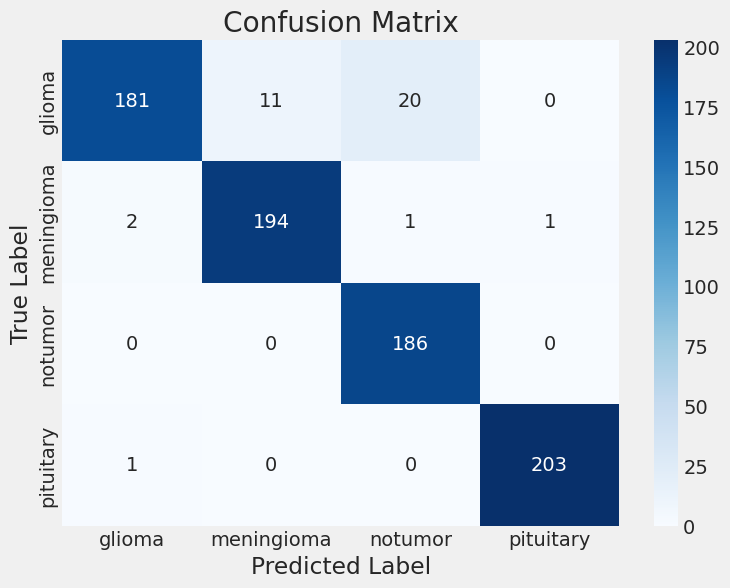

              precision    recall  f1-score   support

      glioma       0.98      0.85      0.91       212
  meningioma       0.95      0.98      0.96       198
     notumor       0.90      1.00      0.95       186
   pituitary       1.00      1.00      1.00       204

    accuracy                           0.95       800
   macro avg       0.96      0.96      0.95       800
weighted avg       0.96      0.95      0.95       800



In [11]:
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes


class_names = list(test_generator.class_indices.keys())


cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=class_names))

💾 Save Model

In [12]:
model.save('Pretrained_model.keras')
print("Saved model")

Saved model


In [13]:
import os
print(os.listdir('.'))

['.config', 'drive', 'Training', 'Pretrained_model.keras', 'Testing', 'sample_data']


```markdown
## Streamlit Frontend Pseudo-code

This pseudo-code outlines a basic Streamlit application to interact with your trained brain tumor classification model. You would typically run this in a separate Python script (`app.py`) and launch it using `streamlit run app.py`.
```

In [17]:
# app.py (This would be a separate Python file)

import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# --- 1. Load the trained model ---
# This path should point to where your 'Pretrained_model.keras' is stored
# If running in Colab, you might need to download it or ensure it's accessible.
@st.cache_resource # Cache the model loading to improve performance
def load_my_model():
    model = tf.keras.models.load_model('Pretrained_model.keras')
    return model

model = load_my_model()

# --- 2. Define image preprocessing function ---
# This should match the preprocessing done during training (e.g., EfficientNet preprocess_input)
def preprocess_image(image):
    image = image.resize((380, 380)) # Resize to target size used in training
    image_array = np.array(image) # Convert PIL image to numpy array
    image_array = np.expand_dims(image_array, axis=0) # Add batch dimension

    # Assuming EfficientNet's preprocess_input was used during training
    # Make sure to import it: `from tensorflow.keras.applications.efficientnet import preprocess_input`
    # image_array = preprocess_input(image_array)
    return image_array

# --- 3. Define class labels ---
# These should match the order of your model's output classes
class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

# --- 4. Streamlit App Layout ---
st.set_page_config(
    page_title="Brain Tumor Classification",
    page_icon="🧠",
    layout="centered"
)

st.title("🧠 Brain Tumor Classification")
st.write("Upload an MRI image to predict if a brain tumor is present and its type.")

# --- 5. Image Upload Widget ---
uploaded_file = st.file_uploader("Choose an MRI image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file)
    st.image(image, caption='Uploaded MRI Image', use_column_width=True)
    st.write("")
    st.write("Classifying...")

    # --- 6. Preprocess and Predict ---
    processed_image = preprocess_image(image)
    predictions = model.predict(processed_image)

    # Get the class with the highest probability
    predicted_class_index = np.argmax(predictions)
    predicted_class = class_labels[predicted_class_index]
    confidence = np.max(predictions) * 100

    # --- 7. Display Results ---
    st.success(f"Prediction: **{predicted_class.upper()}**")
    st.write(f"Confidence: **{confidence:.2f}%**")

    st.subheader("Raw Predictions (Probabilities):")
    # Display probabilities for all classes
    for i, prob in enumerate(predictions[0]):
        st.write(f"- {class_labels[i].capitalize()}: {prob*100:.2f}%")

st.markdown("---")
st.info("Disclaimer: This model is for educational and experimental purposes only and should not be used for medical diagnosis.")

ModuleNotFoundError: No module named 'streamlit'

In [14]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model('Pretrained_model.keras')
print("Model loaded successfully!")

Model loaded successfully!


50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 288ms/step - accuracy: 0.9550 - loss: 0.2174
Loaded Model Test Accuracy: 95.50%
Loaded Model Test Loss: 0.2174
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 295ms/step


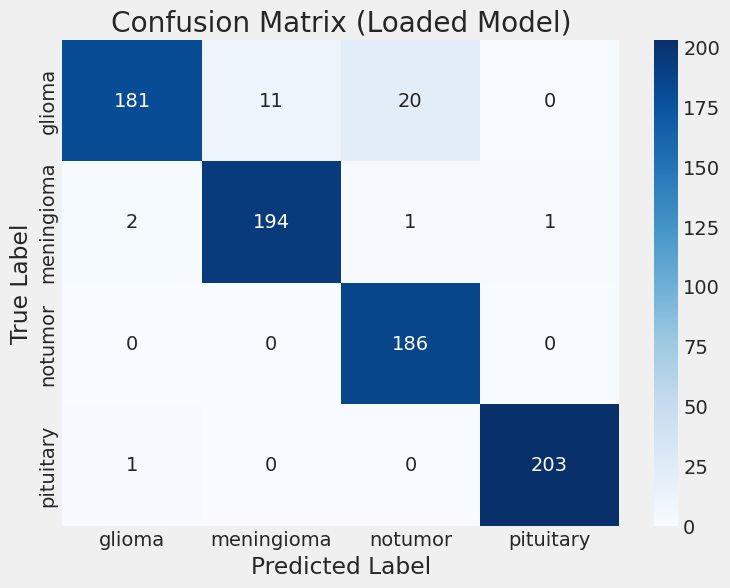

              precision    recall  f1-score   support

      glioma       0.98      0.85      0.91       212
  meningioma       0.95      0.98      0.96       198
     notumor       0.90      1.00      0.95       186
   pituitary       1.00      1.00      1.00       204

    accuracy                           0.95       800
   macro avg       0.96      0.96      0.95       800
weighted avg       0.96      0.95      0.95       800



In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Evaluate the loaded model on the test set
test_loss_loaded, test_acc_loaded = loaded_model.evaluate(test_generator, verbose=1)
print(f"Loaded Model Test Accuracy: {test_acc_loaded*100:.2f}%")
print(f"Loaded Model Test Loss: {test_loss_loaded:.4f}")

# Make predictions with the loaded model
y_pred_loaded = loaded_model.predict(test_generator)
y_pred_classes_loaded = np.argmax(y_pred_loaded, axis=1)
y_true_loaded = test_generator.classes

# Generate and display Confusion Matrix
class_names_loaded = list(test_generator.class_indices.keys())
cm_loaded = confusion_matrix(y_true_loaded, y_pred_classes_loaded)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_loaded, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_loaded, yticklabels=class_names_loaded)
plt.title('Confusion Matrix (Loaded Model)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Display Classification Report
print(classification_report(y_true_loaded, y_pred_classes_loaded, target_names=class_names_loaded))